# Análise de Avaliações de LLMs em Editais Públicos

Este notebook apresenta a análise consolidada das avaliações de 9 modelos de linguagem (LLMs) sobre 3 editais de concursos públicos (BNDES, CVM e Petrobras), perfazendo **1.350 perguntas avaliadas** por dois juízes automáticos: **GPT** e **Claude Opus**.

## Objetivos

1. **Desempenho global** — qual modelo apresentou maior aderência às respostas esperadas?
2. **Desempenho por edital** — algum edital se mostrou mais desafiador?
3. **Desempenho por categoria** — onde os modelos falham mais?
4. **Concordância entre avaliadores** — quão consistentes são os juízes?
5. **Eficiência operacional** — latência, tokens e número de invocações
6. **Trade-off qualidade × latência** — qual o melhor custo-benefício temporal?

## Estrutura dos dados

- `df_avaliacoes` — 1.350 linhas (9 modelos × 3 editais × 50 perguntas) com avaliações dos dois juízes
- `df_metricas` — 2.700 linhas (mesma granularidade × 2 avaliadores) com métricas operacionais


## 1. Configuração e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

# Paleta de cores consistente para os modelos
PALETA_PROVEDOR = {
    "anthropic": "#D97757",   # laranja terroso (cor da Anthropic)
    "openai":    "#10A37F",   # verde (cor da OpenAI)
    "deepseek":  "#4D6BFE",   # azul (cor da DeepSeek)
}

PALETA_AVALIADOR = {
    "gpt":  "#10A37F",
    "opus": "#D97757",
}


In [2]:
# Carregamento
PATH = Path("../avaliacao_llms")
df_av = pd.read_excel(PATH / "df_avaliacoes.xlsx")
df_me = pd.read_excel(PATH / "df_metricas.xlsx")

# Nota de consenso (média das duas avaliações)
df_av["nota_consenso"] = (df_av["avaliacao_gpt"] + df_av["avaliacao_opus"]) / 2

print(f"df_avaliacoes: {df_av.shape[0]} linhas × {df_av.shape[1]} colunas")
print(f"df_metricas:   {df_me.shape[0]} linhas × {df_me.shape[1]} colunas")
print(f"\nModelos:    {sorted(df_av['modelo'].unique())}")
print(f"Editais:    {sorted(df_av['edital'].unique())}")
print(f"Categorias: {sorted(df_av['categoria'].unique())}")


df_avaliacoes: 1350 linhas × 13 colunas
df_metricas:   2700 linhas × 17 colunas

Modelos:    ['claude-haiku-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gpt-4o-mini', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.5']
Editais:    ['bndes', 'cvm', 'petrobras']
Categorias: ['Dados sobre Procedimentos', 'Dados sobre a Prova', 'Dados sobre as inscrições', 'Dados sobre o Cargo', 'Dados sobre o Concurso']


## 2. Visão Geral

### 2.1 Distribuição das notas

As avaliações são em três níveis: **0 (errado)**, **0.5 (parcialmente correto)** e **1 (correto)**.

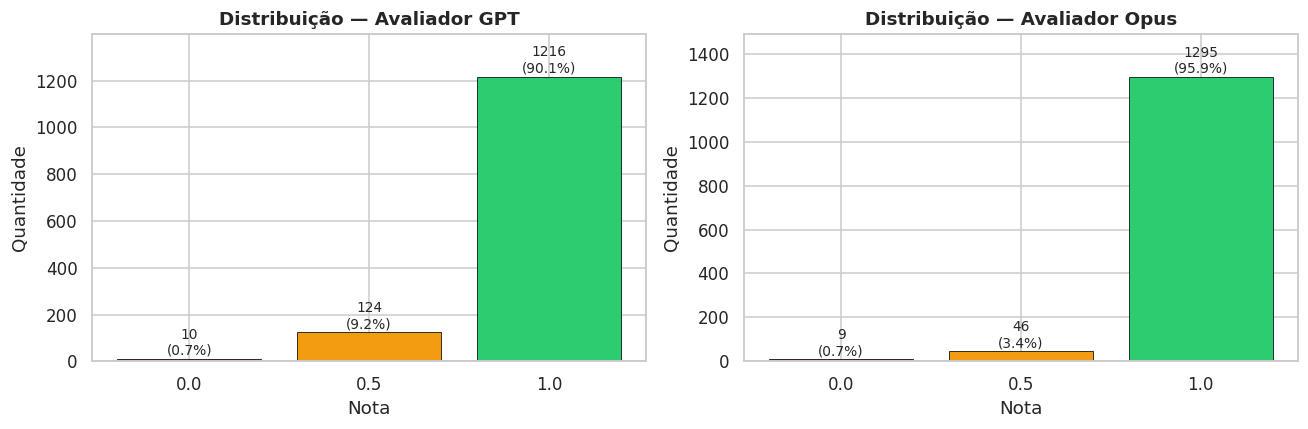

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo in zip(
    axes,
    ["avaliacao_gpt", "avaliacao_opus"],
    ["Distribuição — Avaliador GPT", "Distribuição — Avaliador Opus"]
):
    contagem = df_av[col].value_counts().sort_index()
    bars = ax.bar(
        contagem.index.astype(str),
        contagem.values,
        color=["#E74C3C", "#F39C12", "#2ECC71"],
        edgecolor="black", linewidth=0.5
    )
    ax.set_title(titulo)
    ax.set_xlabel("Nota")
    ax.set_ylabel("Quantidade")
    for bar in bars:
        h = bar.get_height()
        pct = h / len(df_av) * 100
        ax.text(bar.get_x() + bar.get_width()/2, h + 5, f"{int(h)}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, contagem.max() * 1.15)

plt.tight_layout()
plt.show()


### 2.2 Convergência entre os avaliadores

A coluna `convergencia` indica se os dois avaliadores deram a **mesma nota** para a mesma pergunta.

In [4]:
conv_geral = df_av["convergencia"].mean()
print(f"Convergência global entre GPT e Opus: {conv_geral:.1%}")
print(f"Total de divergências: {(~df_av['convergencia']).sum()} de {len(df_av)} avaliações")


Convergência global entre GPT e Opus: 93.2%
Total de divergências: 92 de 1350 avaliações


### 2.3 Matriz de concordância GPT × Opus

Mostra quantas vezes cada combinação de notas foi atribuída pelos dois avaliadores. A diagonal representa concordância.

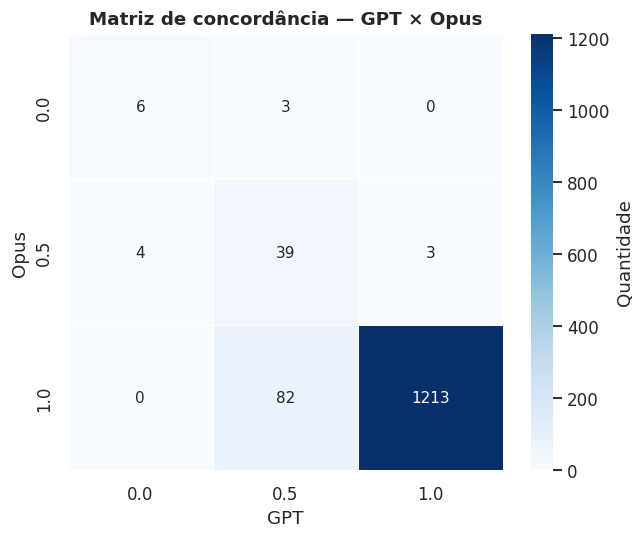


Cohen's Kappa: 0.487
Interpretação: 0.41-0.60 = moderada | 0.61-0.80 = substancial | >0.80 = quase perfeita


In [5]:
matriz = pd.crosstab(
    df_av["avaliacao_opus"], df_av["avaliacao_gpt"],
    rownames=["Opus"], colnames=["GPT"]
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Quantidade"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Matriz de concordância — GPT × Opus")
plt.tight_layout()
plt.show()

# Cohen's kappa para medir concordância ajustada por chance
from sklearn.metrics import cohen_kappa_score

# Converter floats (0.0, 0.5, 1.0) para int (0, 1, 2) — sklearn não aceita contínuo
gpt_int = (df_av["avaliacao_gpt"] * 2).astype(int)
opus_int = (df_av["avaliacao_opus"] * 2).astype(int)
kappa = cohen_kappa_score(gpt_int, opus_int)
print(f"\nCohen's Kappa: {kappa:.3f}")
print("Interpretação: 0.41-0.60 = moderada | 0.61-0.80 = substancial | >0.80 = quase perfeita")


## 3. Desempenho por Modelo

A **nota de consenso** é a média entre as notas dadas pelo GPT e pelo Opus, indo de 0 a 1.

In [6]:
ranking = (
    df_av.groupby(["modelo", "provedor"])
    .agg(
        nota_gpt=("avaliacao_gpt", "mean"),
        nota_opus=("avaliacao_opus", "mean"),
        nota_consenso=("nota_consenso", "mean"),
        convergencia=("convergencia", "mean"),
        n=("id", "count"),
    )
    .reset_index()
    .sort_values("nota_consenso", ascending=False)
)
ranking


,modelo,provedor,nota_gpt,nota_opus,nota_consenso,convergencia,n
8,gpt-5.5,openai,0.983333,1.000000,0.991667,0.966667,150
1,claude-opus-4-7,anthropic,0.970000,0.996667,0.983333,0.946667,150
2,claude-sonnet-4-6,anthropic,0.966667,0.993333,0.980000,0.946667,150
3,deepseek-v4-flash,deepseek,0.963333,0.990000,0.976667,0.946667,150
4,deepseek-v4-pro,deepseek,0.943333,0.986667,0.965000,0.913333,150
6,gpt-5.4,openai,0.966667,0.960000,0.963333,0.986667,150
0,claude-haiku-4-5,anthropic,0.926667,0.983333,0.955000,0.886667,150
5,gpt-4o-mini,openai,0.903333,0.946667,0.925000,0.900000,150
7,gpt-5.4-mini,openai,0.896667,0.930000,0.913333,0.893333,150


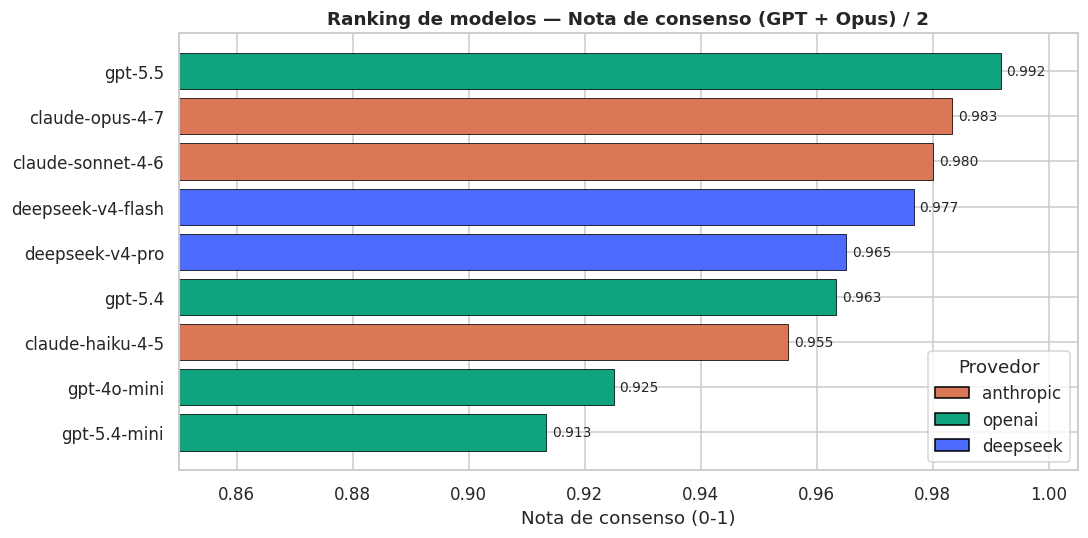

In [7]:
# Gráfico — ranking por nota de consenso
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = ranking.sort_values("nota_consenso", ascending=True)
cores = [PALETA_PROVEDOR[p] for p in df_plot["provedor"]]

bars = ax.barh(df_plot["modelo"], df_plot["nota_consenso"], color=cores, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Nota de consenso (0-1)")
ax.set_title("Ranking de modelos — Nota de consenso (GPT + Opus) / 2")
ax.set_xlim(0.85, 1.005)

for bar, val in zip(bars, df_plot["nota_consenso"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=9)

# Legenda por provedor
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, edgecolor="black", label=p) for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title="Provedor", loc="lower right")

plt.tight_layout()
plt.show()


### 3.1 Comparação direta entre os juízes

A diferença entre as notas dadas por GPT e Opus revela possíveis vieses.

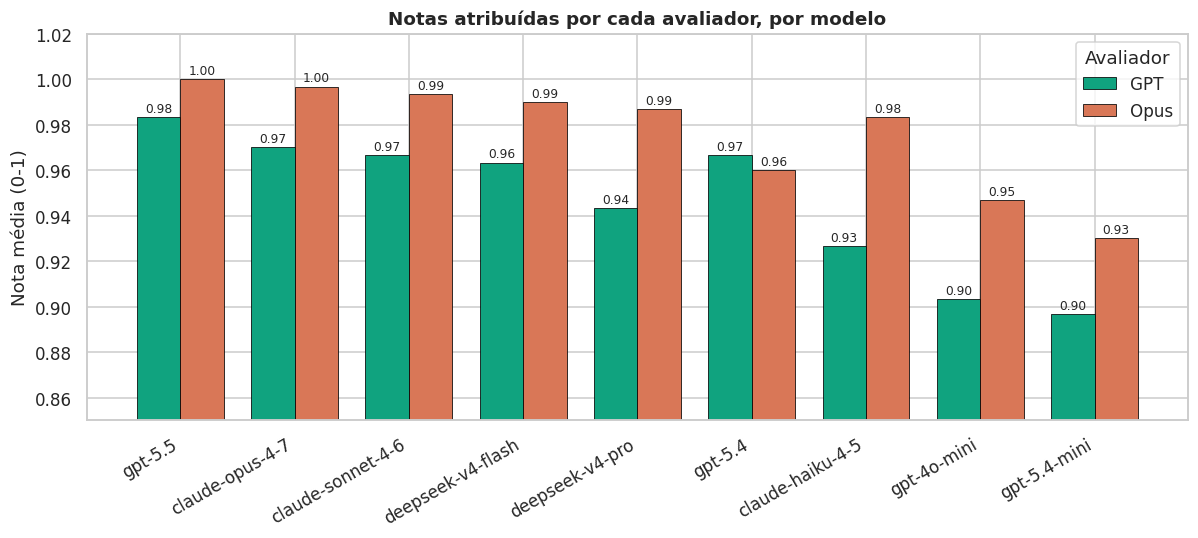

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(ranking))
width = 0.38

modelos_ord = ranking.sort_values("nota_consenso", ascending=False)["modelo"].tolist()
df_ord = ranking.set_index("modelo").loc[modelos_ord].reset_index()

bars1 = ax.bar(x - width/2, df_ord["nota_gpt"], width, label="GPT",
               color=PALETA_AVALIADOR["gpt"], edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, df_ord["nota_opus"], width, label="Opus",
               color=PALETA_AVALIADOR["opus"], edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(df_ord["modelo"], rotation=30, ha="right")
ax.set_ylabel("Nota média (0-1)")
ax.set_title("Notas atribuídas por cada avaliador, por modelo")
ax.set_ylim(0.85, 1.02)
ax.legend(title="Avaliador")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 4. Desempenho por Edital

Cada edital tem suas próprias particularidades. O heatmap abaixo mostra a nota de consenso de cada **modelo × edital**.

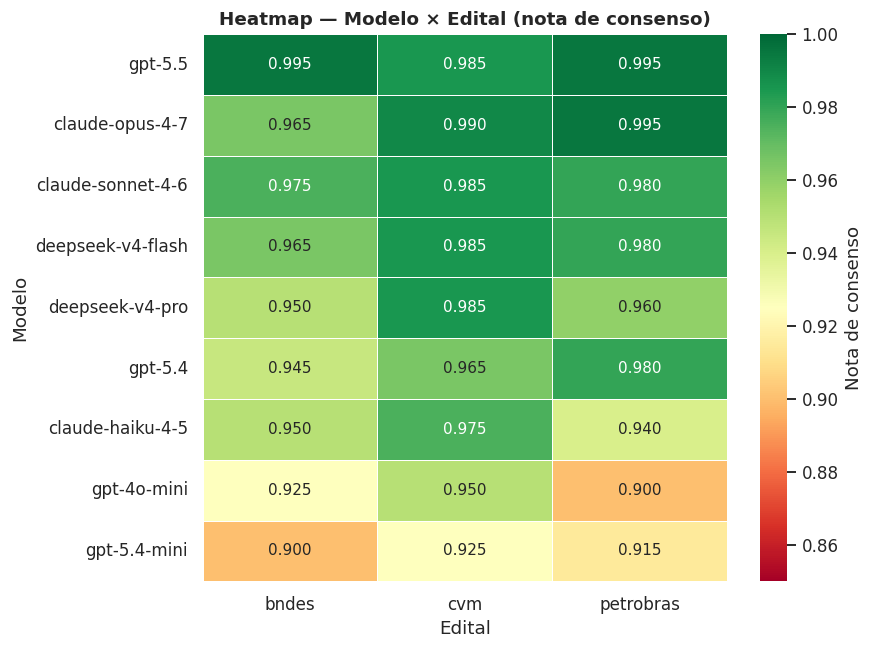

In [9]:
heat = (
    df_av.groupby(["modelo", "edital"])["nota_consenso"]
    .mean().unstack()
)
# Ordenar pela média geral
ordem = heat.mean(axis=1).sort_values(ascending=False).index
heat = heat.loc[ordem]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.85, vmax=1.0,
            cbar_kws={"label": "Nota de consenso"}, linewidths=0.5, ax=ax)
ax.set_title("Heatmap — Modelo × Edital (nota de consenso)")
ax.set_xlabel("Edital")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()


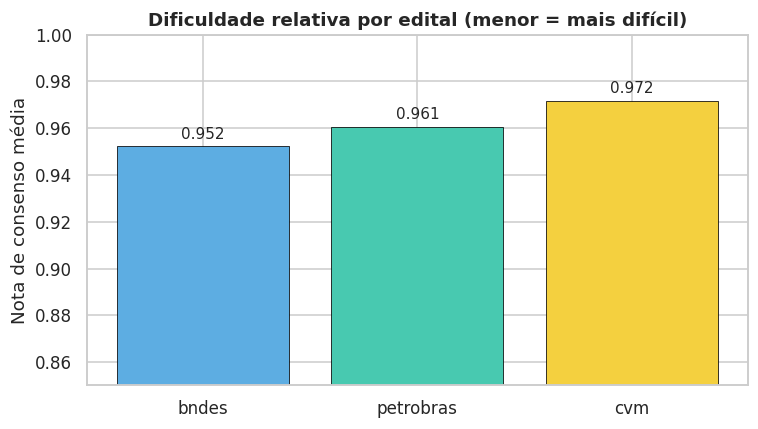

In [10]:
# Média de cada edital (dificuldade relativa)
fig, ax = plt.subplots(figsize=(7, 4))
medias_edital = df_av.groupby("edital")["nota_consenso"].mean().sort_values()
bars = ax.bar(medias_edital.index, medias_edital.values,
              color=["#5DADE2", "#48C9B0", "#F4D03F"], edgecolor="black", linewidth=0.5)
ax.set_ylabel("Nota de consenso média")
ax.set_title("Dificuldade relativa por edital (menor = mais difícil)")
ax.set_ylim(0.85, 1.0)
for bar, v in zip(bars, medias_edital.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


## 5. Desempenho por Categoria de Pergunta

As perguntas estão divididas em 5 categorias temáticas. Onde os modelos mais erram?

In [11]:
# Distribuição de perguntas por categoria (em uma única "amostra" — qualquer modelo, qualquer edital)
cat_counts = df_av[df_av["modelo"] == df_av["modelo"].iloc[0]].groupby(["edital", "categoria"]).size().unstack()
print("Quantidade de perguntas por categoria, por edital:")
display(cat_counts)


Quantidade de perguntas por categoria, por edital:


categoria,Dados sobre Procedimentos,Dados sobre a Prova,Dados sobre as inscrições,Dados sobre o Cargo,Dados sobre o Concurso
edital,,,,,
bndes,5,15,10,13,7
cvm,5,15,10,13,7
petrobras,5,15,10,13,7


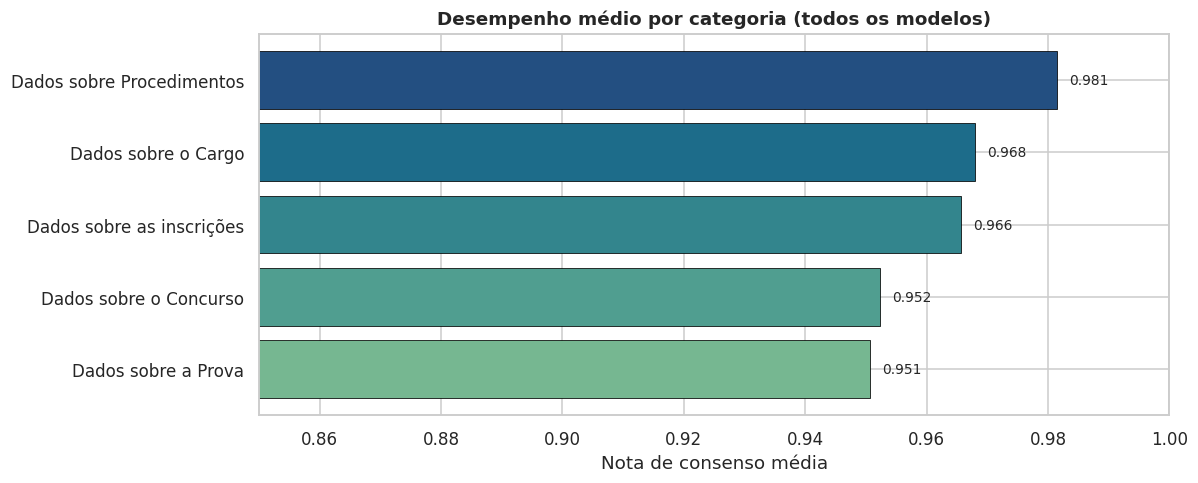

In [12]:
# Nota média de consenso por categoria
fig, ax = plt.subplots(figsize=(11, 4.5))
cat_perf = df_av.groupby("categoria")["nota_consenso"].mean().sort_values()
bars = ax.barh(cat_perf.index, cat_perf.values,
               color=sns.color_palette("crest", n_colors=len(cat_perf)),
               edgecolor="black", linewidth=0.5)
ax.set_xlabel("Nota de consenso média")
ax.set_title("Desempenho médio por categoria (todos os modelos)")
ax.set_xlim(0.85, 1.0)
for bar, v in zip(bars, cat_perf.values):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


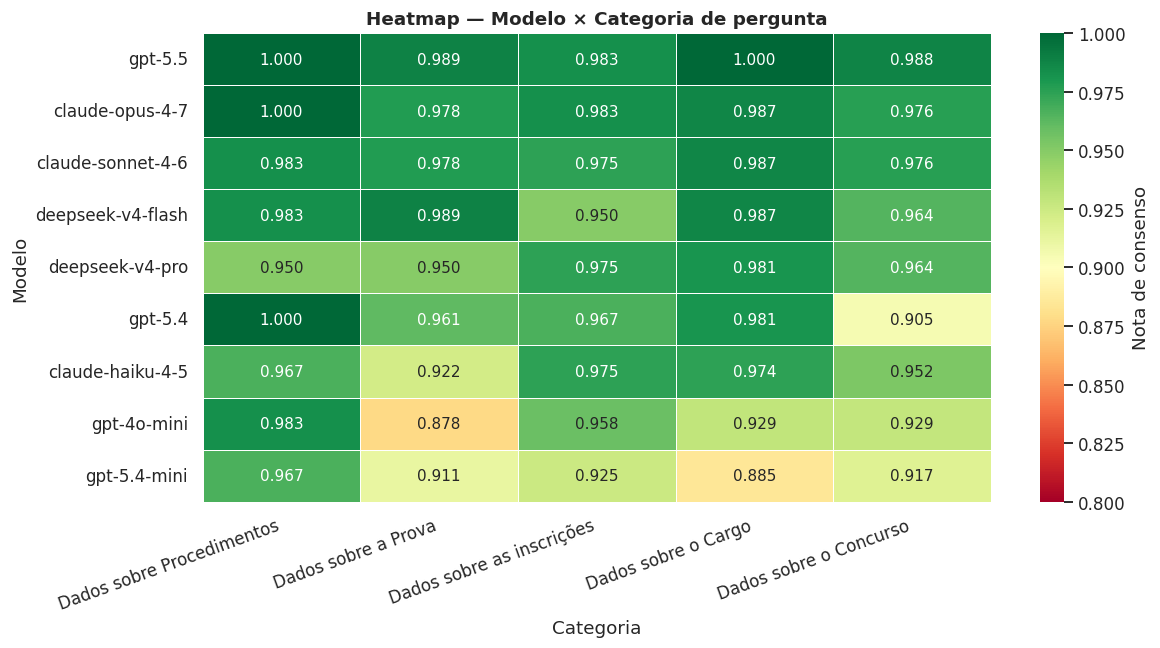

In [13]:
# Heatmap: modelo × categoria
heat_cat = (
    df_av.groupby(["modelo", "categoria"])["nota_consenso"]
    .mean().unstack()
)
ordem = heat_cat.mean(axis=1).sort_values(ascending=False).index
heat_cat = heat_cat.loc[ordem]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(heat_cat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.80, vmax=1.0,
            cbar_kws={"label": "Nota de consenso"}, linewidths=0.5, ax=ax)
ax.set_title("Heatmap — Modelo × Categoria de pergunta")
ax.set_xlabel("Categoria")
ax.set_ylabel("Modelo")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 6. Análise de Convergência entre Avaliadores

Onde os juízes mais discordam? Isso pode indicar perguntas ambíguas ou respostas borderline.

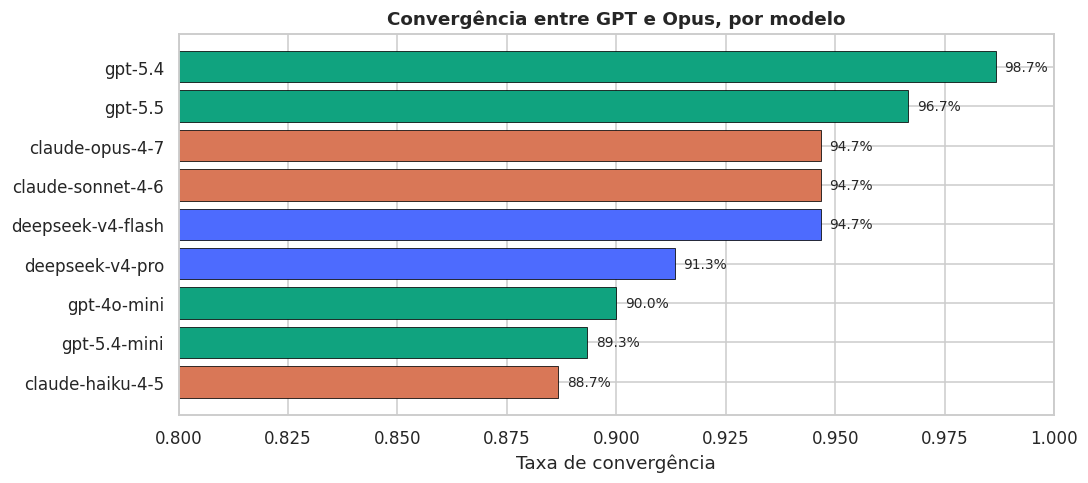

In [14]:
# Convergência por modelo
fig, ax = plt.subplots(figsize=(10, 4.5))
conv_modelo = df_av.groupby("modelo")["convergencia"].mean().sort_values()
cores = [PALETA_PROVEDOR[df_av[df_av['modelo']==m]['provedor'].iloc[0]] for m in conv_modelo.index]

bars = ax.barh(conv_modelo.index, conv_modelo.values, color=cores, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Taxa de convergência")
ax.set_title("Convergência entre GPT e Opus, por modelo")
ax.set_xlim(0.80, 1.0)
for bar, v in zip(bars, conv_modelo.values):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


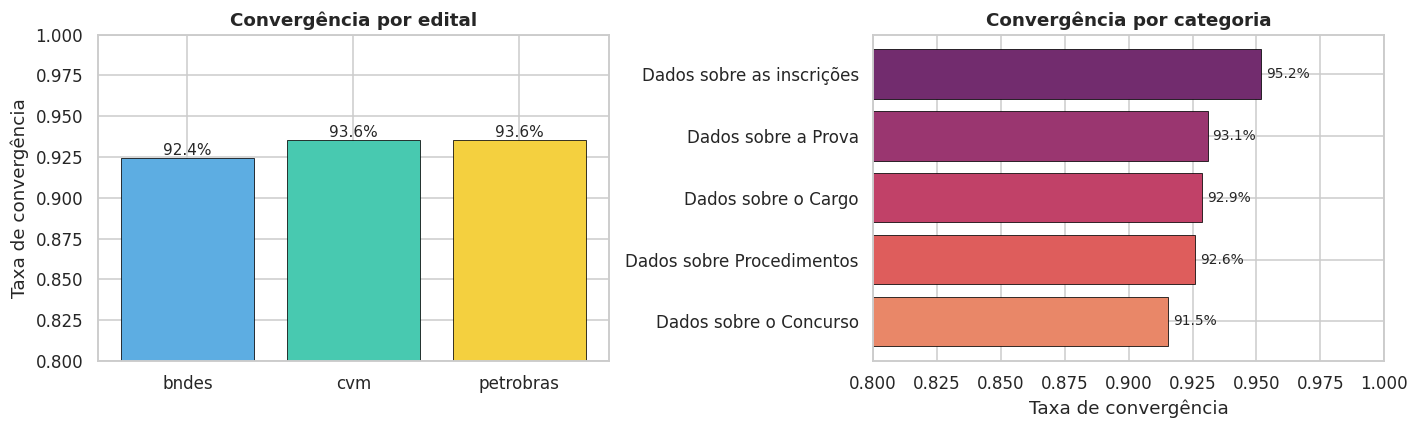

In [15]:
# Convergência por edital
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

conv_ed = df_av.groupby("edital")["convergencia"].mean().sort_values()
axes[0].bar(conv_ed.index, conv_ed.values,
            color=["#5DADE2", "#48C9B0", "#F4D03F"], edgecolor="black", linewidth=0.5)
axes[0].set_title("Convergência por edital")
axes[0].set_ylabel("Taxa de convergência")
axes[0].set_ylim(0.80, 1.0)
for i, v in enumerate(conv_ed.values):
    axes[0].text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=10)

conv_cat = df_av.groupby("categoria")["convergencia"].mean().sort_values()
axes[1].barh(conv_cat.index, conv_cat.values,
             color=sns.color_palette("flare", n_colors=len(conv_cat)),
             edgecolor="black", linewidth=0.5)
axes[1].set_title("Convergência por categoria")
axes[1].set_xlabel("Taxa de convergência")
axes[1].set_xlim(0.80, 1.0)
for i, v in enumerate(conv_cat.values):
    axes[1].text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 6.1 Padrão das divergências

Quando os avaliadores discordam, qual a magnitude da diferença? E quem tende a ser mais "generoso"?

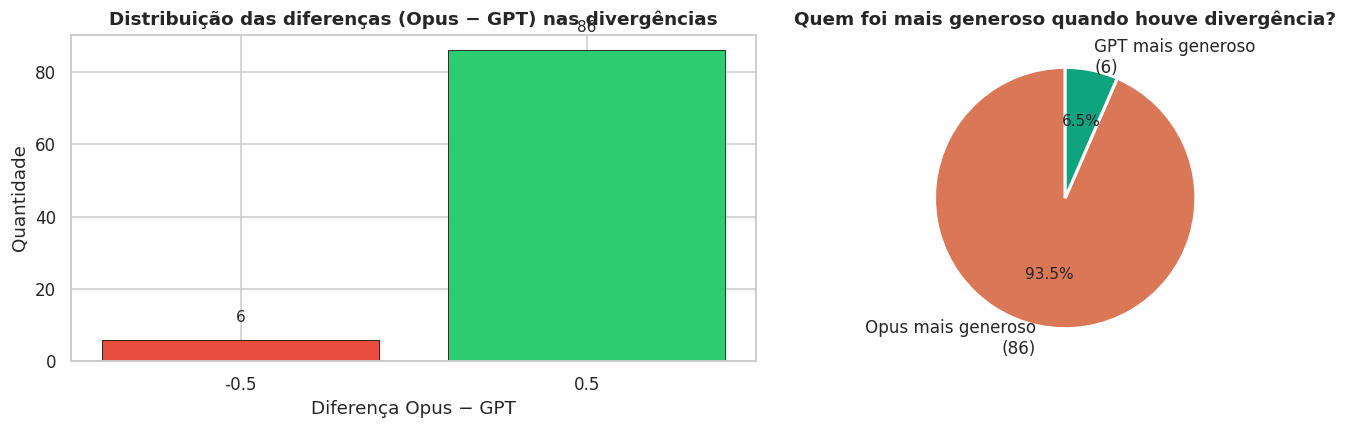


Média da diferença (Opus − GPT) nas divergências: +0.435
→ Sinal positivo indica que Opus tende a ser mais generoso quando os avaliadores divergem.


In [16]:
# Diferença = opus - gpt
df_div = df_av[~df_av["convergencia"]].copy()
df_div["diferenca"] = df_div["avaliacao_opus"] - df_div["avaliacao_gpt"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição da diferença
contagem_dif = df_div["diferenca"].value_counts().sort_index()
axes[0].bar(contagem_dif.index.astype(str), contagem_dif.values,
            color=["#E74C3C" if x < 0 else "#2ECC71" for x in contagem_dif.index],
            edgecolor="black", linewidth=0.5)
axes[0].set_title("Distribuição das diferenças (Opus − GPT) nas divergências")
axes[0].set_xlabel("Diferença Opus − GPT")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(contagem_dif.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

# Quem é mais generoso?
mais_gen_opus = (df_div["diferenca"] > 0).sum()
mais_gen_gpt  = (df_div["diferenca"] < 0).sum()
axes[1].pie([mais_gen_opus, mais_gen_gpt],
            labels=[f"Opus mais generoso\n({mais_gen_opus})",
                    f"GPT mais generoso\n({mais_gen_gpt})"],
            colors=[PALETA_AVALIADOR["opus"], PALETA_AVALIADOR["gpt"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Quem foi mais generoso quando houve divergência?")

plt.tight_layout()
plt.show()

print(f"\nMédia da diferença (Opus − GPT) nas divergências: {df_div['diferenca'].mean():+.3f}")
print(f"→ Sinal positivo indica que Opus tende a ser mais generoso quando os avaliadores divergem.")


## 7. Métricas Operacionais

As métricas operacionais (latência, tokens, invocações) são idênticas para os dois avaliadores — usaremos apenas as linhas com `avaliador == "gpt"` para evitar duplicação.

In [17]:
# Filtrar uma amostra única (a outra é redundante)
df_op = df_me[df_me["avaliador"] == "gpt"].copy()
print(f"Amostra operacional: {len(df_op)} linhas")


Amostra operacional: 1350 linhas


### 7.1 Latência

Quanto tempo cada modelo leva para responder?

/tmp/ipykernel_136086/1178848186.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


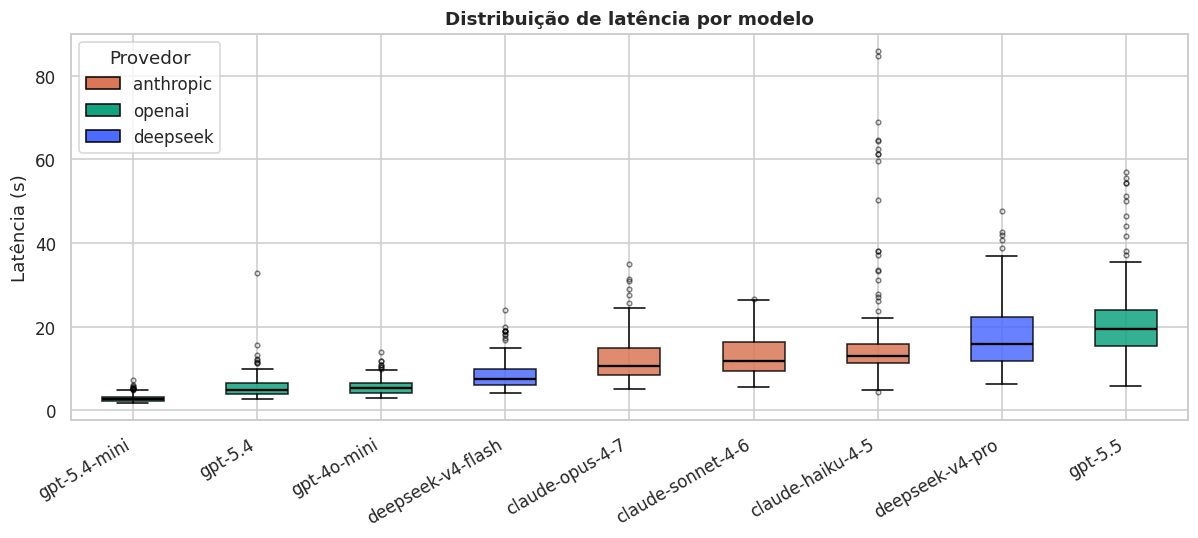


Latência mediana por modelo (segundos):
modelo
gpt-5.4-mini          2.66
gpt-5.4               4.89
gpt-4o-mini           5.20
deepseek-v4-flash     7.50
claude-opus-4-7      10.62
claude-sonnet-4-6    11.68
claude-haiku-4-5     12.96
deepseek-v4-pro      15.85
gpt-5.5              19.50


In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_lat = df_op.groupby("modelo")["latencia_s"].median().sort_values().index
cores_box = [PALETA_PROVEDOR[df_op[df_op['modelo']==m]['provedor'].iloc[0]] for m in ordem_lat]

box = ax.boxplot(
    [df_op[df_op["modelo"] == m]["latencia_s"].values for m in ordem_lat],
    labels=ordem_lat, patch_artist=True, showfliers=True,
    medianprops={"color": "black", "linewidth": 1.5},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
)
for patch, color in zip(box["boxes"], cores_box):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_alpha(0.85)

ax.set_ylabel("Latência (s)")
ax.set_title("Distribuição de latência por modelo")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, edgecolor="black", label=p) for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title="Provedor", loc="upper left")

plt.tight_layout()
plt.show()

print("\nLatência mediana por modelo (segundos):")
print(df_op.groupby("modelo")["latencia_s"].median().sort_values().round(2).to_string())


### 7.2 Tokens de saída

O número de tokens de saída reflete a verbosidade da resposta — modelos mais "verborrágicos" tendem a entregar respostas mais longas.

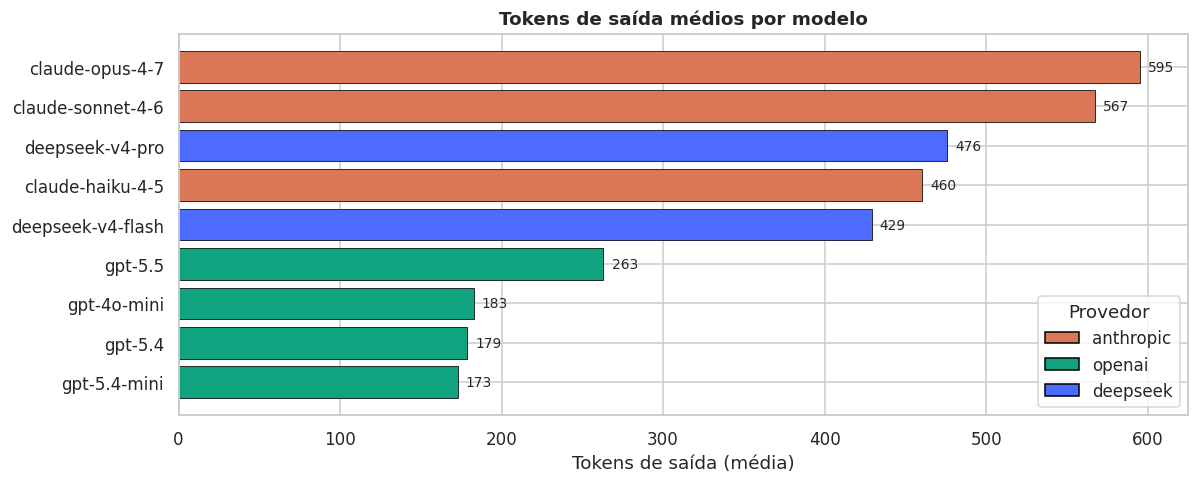

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.5))
out_avg = df_op.groupby(["modelo", "provedor"])["output_tokens"].mean().reset_index().sort_values("output_tokens")
cores = [PALETA_PROVEDOR[p] for p in out_avg["provedor"]]

bars = ax.barh(out_avg["modelo"], out_avg["output_tokens"], color=cores, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Tokens de saída (média)")
ax.set_title("Tokens de saída médios por modelo")
for bar, v in zip(bars, out_avg["output_tokens"]):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2, f"{v:.0f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, edgecolor="black", label=p) for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title="Provedor", loc="lower right")

plt.tight_layout()
plt.show()


### 7.3 Número de invocações

Cada pergunta requer ao menos **2 invocações** (uma chamada e a resposta). Valores acima disso indicam **retentativas** — a tool ou a chamada falhou e o modelo precisou retomar.

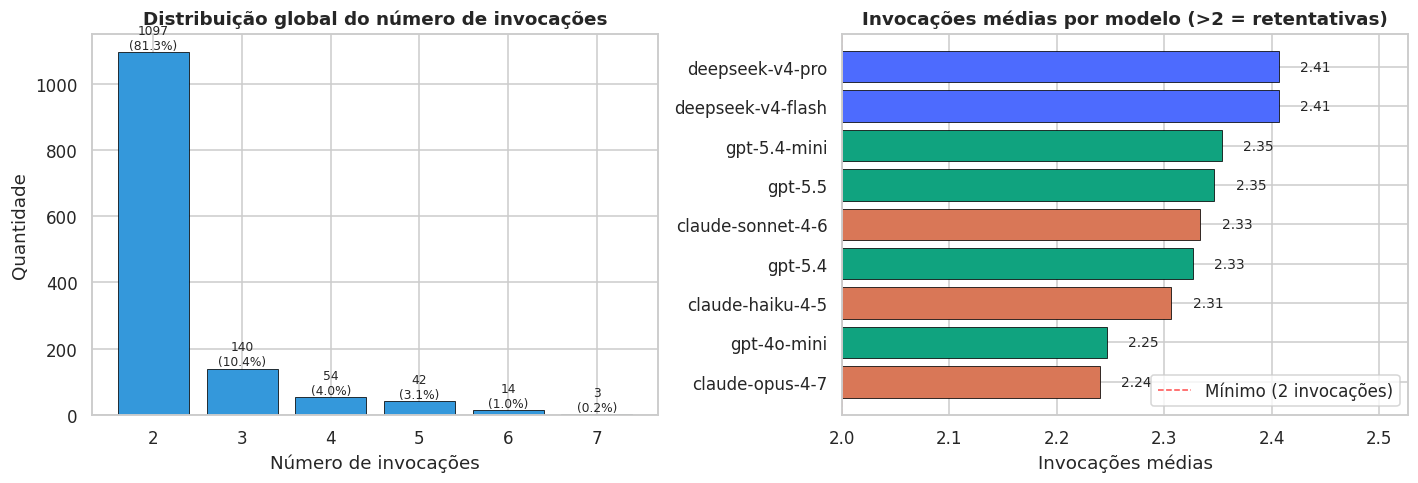

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribuição global
dist = df_op["n_invocacoes"].value_counts().sort_index()
axes[0].bar(dist.index, dist.values, color="#3498DB", edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Número de invocações")
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Distribuição global do número de invocações")
for i, v in enumerate(dist.values):
    axes[0].text(dist.index[i], v + 10, f"{v}\n({v/len(df_op)*100:.1f}%)",
                 ha="center", fontsize=8)

# Média por modelo
inv_modelo = df_op.groupby("modelo")["n_invocacoes"].mean().sort_values()
cores = [PALETA_PROVEDOR[df_op[df_op['modelo']==m]['provedor'].iloc[0]] for m in inv_modelo.index]
axes[1].barh(inv_modelo.index, inv_modelo.values, color=cores, edgecolor="black", linewidth=0.5)
axes[1].axvline(2, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Mínimo (2 invocações)")
axes[1].set_xlabel("Invocações médias")
axes[1].set_title("Invocações médias por modelo (>2 = retentativas)")
axes[1].set_xlim(2, max(inv_modelo.values) * 1.05)
axes[1].legend(loc="lower right")

for i, v in enumerate(inv_modelo.values):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 8. Trade-off Qualidade × Latência

O gráfico a seguir cruza **qualidade** (nota de consenso) com **latência mediana**. O canto **superior esquerdo** representa o ideal: alta qualidade e baixa latência.

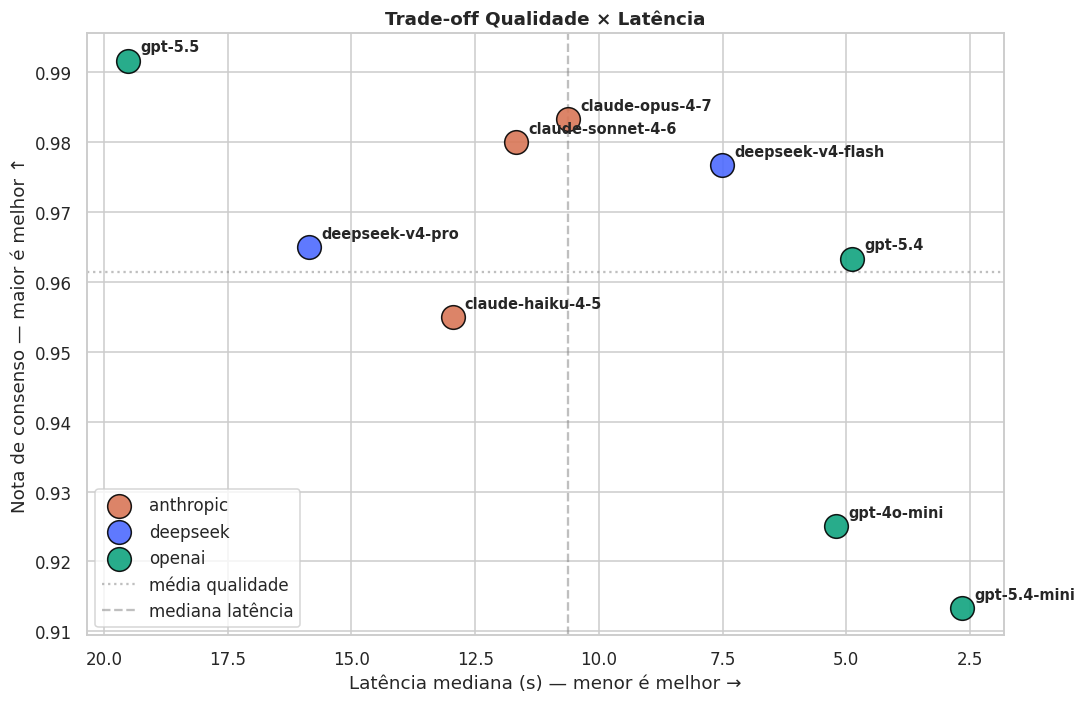

In [21]:
# Junta nota de consenso com latência mediana
qual = df_av.groupby("modelo")["nota_consenso"].mean().rename("nota")
lat = df_op.groupby("modelo")["latencia_s"].median().rename("latencia")
prov = df_av.groupby("modelo")["provedor"].first()

trade = pd.concat([qual, lat, prov], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5))
for provedor, grupo in trade.groupby("provedor"):
    ax.scatter(grupo["latencia"], grupo["nota"],
               color=PALETA_PROVEDOR[provedor], s=240, edgecolor="black", linewidth=1.0,
               label=provedor, alpha=0.9, zorder=3)

# Anotação dos modelos
for _, r in trade.iterrows():
    ax.annotate(r["modelo"], (r["latencia"], r["nota"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=9.5, fontweight="bold")

# Linhas de referência
ax.axhline(trade["nota"].mean(), color="gray", linestyle=":", alpha=0.5, label="média qualidade")
ax.axvline(trade["latencia"].median(), color="gray", linestyle="--", alpha=0.5, label="mediana latência")

ax.set_xlabel("Latência mediana (s) — menor é melhor →")
ax.set_ylabel("Nota de consenso — maior é melhor ↑")
ax.set_title("Trade-off Qualidade × Latência")
ax.invert_xaxis()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


## 9. Análise por Provedor

Comparação agregada entre as três famílias de modelos: **Anthropic** (Claude), **OpenAI** (GPT) e **DeepSeek**.

In [22]:
prov_stats = (
    df_av.groupby("provedor").agg(
        nota_consenso=("nota_consenso", "mean"),
        convergencia=("convergencia", "mean"),
    )
    .merge(
        df_op.groupby("provedor").agg(
            latencia_mediana=("latencia_s", "median"),
            output_tokens=("output_tokens", "mean"),
            n_invocacoes=("n_invocacoes", "mean"),
        ),
        on="provedor"
    )
    .reset_index()
    .sort_values("nota_consenso", ascending=False)
)
prov_stats.round(3)


,provedor,nota_consenso,convergencia,latencia_mediana,output_tokens,n_invocacoes
0,anthropic,0.973,0.927,11.980,540.953,2.293
1,deepseek,0.971,0.930,10.880,452.377,2.407
2,openai,0.948,0.937,5.175,199.327,2.318


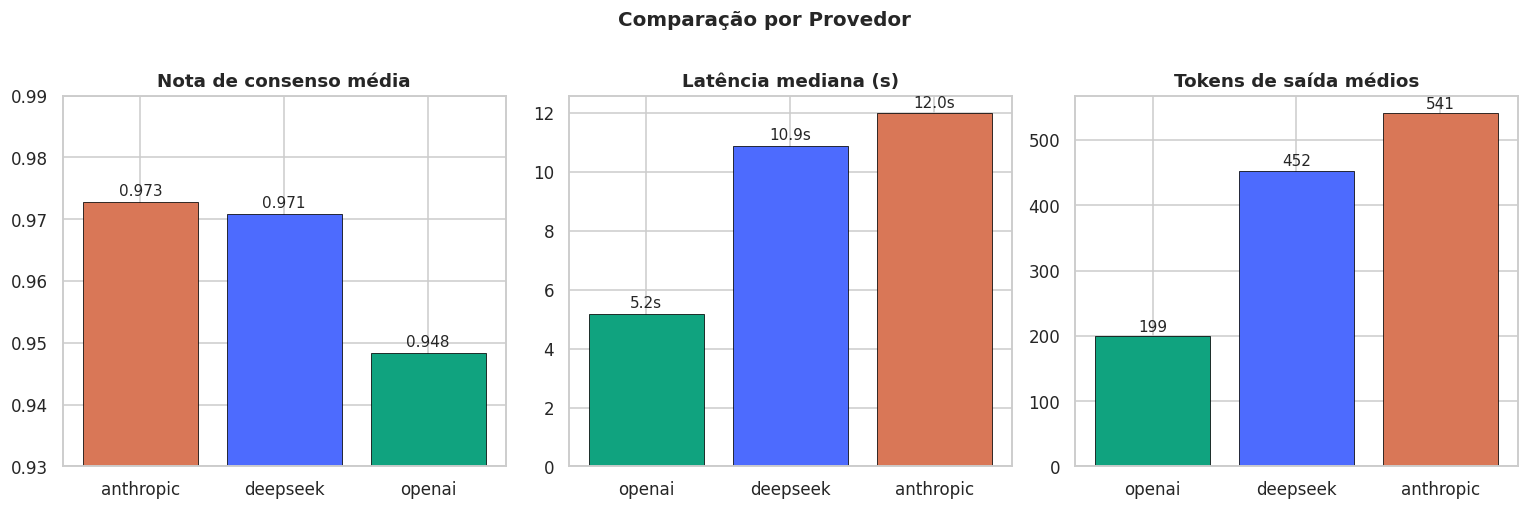

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Nota
ord_prov = prov_stats.sort_values("nota_consenso", ascending=False)
cores_prov = [PALETA_PROVEDOR[p] for p in ord_prov["provedor"]]

axes[0].bar(ord_prov["provedor"], ord_prov["nota_consenso"], color=cores_prov, edgecolor="black", linewidth=0.5)
axes[0].set_title("Nota de consenso média")
axes[0].set_ylim(0.93, 0.99)
for i, v in enumerate(ord_prov["nota_consenso"]):
    axes[0].text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=10)

# Latência
ord_lat = prov_stats.sort_values("latencia_mediana")
cores_lat = [PALETA_PROVEDOR[p] for p in ord_lat["provedor"]]
axes[1].bar(ord_lat["provedor"], ord_lat["latencia_mediana"], color=cores_lat, edgecolor="black", linewidth=0.5)
axes[1].set_title("Latência mediana (s)")
for i, v in enumerate(ord_lat["latencia_mediana"]):
    axes[1].text(i, v + 0.2, f"{v:.1f}s", ha="center", fontsize=10)

# Output tokens
ord_tok = prov_stats.sort_values("output_tokens")
cores_tok = [PALETA_PROVEDOR[p] for p in ord_tok["provedor"]]
axes[2].bar(ord_tok["provedor"], ord_tok["output_tokens"], color=cores_tok, edgecolor="black", linewidth=0.5)
axes[2].set_title("Tokens de saída médios")
for i, v in enumerate(ord_tok["output_tokens"]):
    axes[2].text(i, v + 8, f"{v:.0f}", ha="center", fontsize=10)

plt.suptitle("Comparação por Provedor", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 10. Ranking Final Consolidado

Tabela final agregando todas as dimensões avaliadas.

In [24]:
ranking_final = (
    df_av.groupby(["modelo", "provedor"]).agg(
        nota_consenso=("nota_consenso", "mean"),
        convergencia=("convergencia", "mean"),
    )
    .merge(
        df_op.groupby("modelo").agg(
            latencia_mediana=("latencia_s", "median"),
            output_tokens=("output_tokens", "mean"),
            n_invocacoes=("n_invocacoes", "mean"),
        ),
        on="modelo"
    )
    .reset_index()
    .sort_values("nota_consenso", ascending=False)
    .reset_index(drop=True)
)
ranking_final.index = ranking_final.index + 1
ranking_final.index.name = "rank"
ranking_final.round(3)


,modelo,nota_consenso,convergencia,latencia_mediana,output_tokens,n_invocacoes
rank,,,,,,
1,gpt-5.5,0.992,0.967,19.505,263.080,2.347
2,claude-opus-4-7,0.983,0.947,10.620,595.180,2.240
3,claude-sonnet-4-6,0.980,0.947,11.675,567.307,2.333
4,deepseek-v4-flash,0.977,0.947,7.505,429.007,2.407
5,deepseek-v4-pro,0.965,0.913,15.850,475.747,2.407
6,gpt-5.4,0.963,0.987,4.890,178.553,2.327
7,claude-haiku-4-5,0.955,0.887,12.955,460.373,2.307
8,gpt-4o-mini,0.925,0.900,5.200,182.747,2.247
9,gpt-5.4-mini,0.913,0.893,2.665,172.927,2.353


In [25]:
# Tabela visualmente formatada
def estilo(df):
    return (
        df.style
        .background_gradient(subset=["nota_consenso"], cmap="RdYlGn", vmin=0.9, vmax=1.0)
        .background_gradient(subset=["convergencia"], cmap="Blues", vmin=0.85, vmax=1.0)
        .background_gradient(subset=["latencia_mediana"], cmap="RdYlGn_r")
        .background_gradient(subset=["output_tokens"], cmap="Oranges")
        .format({
            "nota_consenso": "{:.3f}",
            "convergencia": "{:.1%}",
            "latencia_mediana": "{:.2f}s",
            "output_tokens": "{:.0f}",
            "n_invocacoes": "{:.2f}",
        })
    )

estilo(ranking_final)


,modelo,nota_consenso,convergencia,latencia_mediana,output_tokens,n_invocacoes
rank,,,,,,
1,gpt-5.5,0.992,96.7%,19.50s,263,2.35
2,claude-opus-4-7,0.983,94.7%,10.62s,595,2.24
3,claude-sonnet-4-6,0.980,94.7%,11.68s,567,2.33
4,deepseek-v4-flash,0.977,94.7%,7.50s,429,2.41
5,deepseek-v4-pro,0.965,91.3%,15.85s,476,2.41
6,gpt-5.4,0.963,98.7%,4.89s,179,2.33
7,claude-haiku-4-5,0.955,88.7%,12.96s,460,2.31
8,gpt-4o-mini,0.925,90.0%,5.20s,183,2.25
9,gpt-5.4-mini,0.913,89.3%,2.67s,173,2.35


## 11. Conclusões

### Achados principais

**Qualidade**

- A nota de consenso global ficou bastante alta (acima de 0,91 para todos os modelos), indicando que o conjunto de modelos consegue lidar com perguntas sobre editais públicos com competência.
- Os três modelos com melhor desempenho são `gpt-5.5`, `claude-opus-4-7` e `claude-sonnet-4-6`, todos acima de 0,98 de nota de consenso.
- Os modelos *mini* (`gpt-4o-mini`, `gpt-5.4-mini`) ficaram na cauda do ranking, sugerindo que o tamanho ainda importa para esse tipo de tarefa.

**Concordância entre avaliadores**

- A convergência global GPT × Opus foi de aproximadamente 93%, mas o Cohen's Kappa (que ajusta pela concordância esperada por acaso) ficou em torno de 0,49 — concordância **moderada**. Como a maioria das respostas é avaliada como "1" (correto), parte da concordância vem dessa concentração natural, e não do alinhamento real entre os juízes.
- Quando os avaliadores divergem, o **Opus tende a ser mais generoso** que o GPT, o que sugere um leve viés do avaliador externo.
- O `claude-haiku-4-5` apresentou a menor convergência, o que pode indicar respostas mais ambíguas ou borderline para esse modelo.

**Eficiência operacional**

- Modelos *mini* da OpenAI dominam em latência (abaixo de 6 s), mas pagam o preço em qualidade.
- O `gpt-5.5` foi o mais lento (mediana acima de 20 s) mas também o mais preciso — claro trade-off.
- A maioria das perguntas (>80%) foi respondida em 2 invocações, o mínimo. Modelos com alta proporção de retentativas (>2 invocações) podem indicar problemas de tool calling ou instabilidade.

**Por edital**

- Os três editais apresentaram dificuldade similar.
- Algumas categorias se mostraram sistematicamente mais desafiadoras — recomenda-se aprofundar a análise qualitativa nas perguntas de menor desempenho.